# Python Crash Course

Welcome! This single notebook is a short overview of the parts of Python
with a focus on tools that are especially relevant for brain and behavioral sciences. It is
designed to be **worked through by typing and running the code
yourself** (not just reading it, which will likely not teach you much).

It does **not** cover everything in the full chapters (P01-P09), as those provide deeper explainations about
*why* things work. That said, learning the material in the other chapters will likely be easier 
if you do this short course first as you'll then be a little more familar with the syntax and basic concepts.

## How to use this interactive notebook

Run each code cell (Shift+Enter), read the comment above each block, then change a
number or a line and run it again. Repeat until you build intuition and you 
can successfully predict the outcome of each change that you make. 

| Section | Topic |
|---|---|
| 0 | Jupyter survival kit | 
| 1 | Values, variables, and types | 
| 2 | Containers: lists, tuples, dicts, sets | 
| 3 | Control flow and comprehensions | 
| 4 | Functions | 
| 5 | NumPy: arrays and vectorized math | 
| 6 | pandas: tables of trials | 
| 7 | matplotlib: plotting | 
| 8 | Mini-project: analyze a simulated experiment |

Throughout, you'll see some notes with a **Caution** tag. Those mark places where code can
run, seemingly without errors, but still be wrong. These scenarios are intended to highlight 
the importance of using your judgment and knowing the subtlties/quirks of the language (as opposed to relying solely on AI or on naive intuition).

## 0. Jupyter survival kit

A notebook is a list of **cells**. A cell is either **text** (Markdown, like this
one) or **code** (Python, like the cell immediately below). To run a code cell, click it and press **Shift+Enter**.
The value of the *last line* of a code cell is displayed automatically; for
anything that you want to see that is on an earlier line, use `print(...)`.

In [2]:
# this is a code cell that can be run with Shift+Enter
2 + 2          # the value returned by the last line is shown automatically

4

In [2]:
# use print() when you want to show more than just the last line
print("hello")
print(3 * 7)

hello
21


## 1. Values, variables, and types

A **variable** is a name for a value. Python figures out the **type** for you (e.g. it will figure out that 
7 is an integer but that 7.0 is a float).
The four atomic types you will use constantly are integers, floats, strings, and
booleans (note: 'atomic' types are built-in primitive data types that represent a single, indivisible value)

In [4]:
subject_id = 7            # int   (whole number)
contrast = 7.0            # float (decimal number)
condition = "congruent"   # str   (text, in quotes)
correct = True            # bool  (True or False)

# type() tells you what something is
print(type(subject_id), type(contrast), type(condition), type(correct))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


In [5]:
# f-strings build text out of variables: note the .0f term after the : indicates how many digits to the right of the decimal when printing
reaction_time = 0.412
print(f"subject {subject_id}: {condition} trial, RT = {reaction_time*1000:.2f} ms")

subject 7: congruent trial, RT = 412.00 ms


### Arithmetic works as you'd expect on atomic data types, and note the two kinds of division (float and integer, or floor, division)


In [5]:
print(7 / 2)     # 3.5  -> normal (float) division
print(7 // 2)    # 3    -> integer (floor) division
print(7 % 2)     # 1    -> remainder (modulo)
print(2 ** 10)   # 1024 -> exponent

3.5
3
1
1024


### *Be Careful*
Floats are not always exact:
`0.1 + 0.2` is `0.30000000000000004`, not `0.3`, so `0.1 + 0.2 == 0.3` is `False`.
Never compare floats with `==`. Instead, use `math.isclose(a, b)` or `numpy.isclose`. This
can lead to silent errors that lead to inaccurate outcmes.

In [10]:
print(0.1 + 0.2)            # not exactly 0.3
print((0.1 + 0.2) == 0.3)   # False

# now compare the result of 0.1 + 0.2 to 0.3 to determine if its 
# really really close (default of within 1e-09, but change by specifying the 
# abs_tol param directly e.g. math.isclose(0.1 + 0.2, 0.3, abs_tol=2.220446049250313e-16)
import math
print(math.isclose(0.1 + 0.2, 0.3))   # True

0.30000000000000004
False
True


## 2. Containers: lists, tuples, dicts, sets

Real data comes often comes in collections (e.g. an array of numbers) that can be stored
in a 'container'.
Technically, any object that you can check membership using the `in` operator is classified as a container.

The four native Python container types are:
* **list** `[...]` - an ordered, *changeable* (sometimes called *mutable*) sequence (a column of RTs).
* **tuple** `(...)` - an ordered, *unchangeable* (*immutable**) sequence (a coordinate, a record).
* **dict** `{key: value}` - an ordered (after Python 3.5) lookup table (condition -> list of RTs).
* **set** `{...}` - a *changeable* unordered collection of *unique* items.

### *Be Careful*
Python counts from 0 (Matlab counts from 1). Critical to keep this in mind when dealing with containers as off-by-one indexing errors are super easy to make and are infamous for wrecking analysis pipelines!

In [7]:
# a LIST of reaction times (ms)
rts = [412, 520, 380, 660, 290, 505]
print(rts[0])      # first element (Python counts from 0!)
print(rts[-1])     # last element
print(rts[:3])     # slice: first three
print(len(rts))    # how many

rts.append(450)    # add to the end
print(rts)

412
505
[412, 520, 380]
6
[412, 520, 380, 660, 290, 505, 450]


In [8]:
# a TUPLE -- like a list but immutable; great for fixed records
trial = (7, "congruent", 0.412)     # (subject, condition, rt)
subject, cond, rt = trial            # unpack into three names at once
print(subject, cond, rt)

7 congruent 0.412


In [9]:
# a DICT maps keys to values
mean_rt_by_condition = {"congruent": 488.0, "incongruent": 640.0}
print(mean_rt_by_condition["incongruent"])     # look up by key

# loop over keys and values together
for condition, mean_rt in mean_rt_by_condition.items():
    print(f"{condition}: {mean_rt} ms")

640.0
congruent: 488.0 ms
incongruent: 640.0 ms


In [10]:
# a SET keeps only unique items
stimuli_shown = {101, 102, 103, 102, 101}
print(stimuli_shown)                  # duplicates dropped
print(102 in stimuli_shown)           # fast membership test

{101, 102, 103}
True


### *Be Careful*
0-based indexing and exclusive slices
Python counts from **0**, and a slice `a[start:stop]` *excludes* `stop`. So
`rts[0]` is the first trial and `rts[0:3]` is trials 0, 1, 2 (three items, not
four). Off-by-one errors here silently drop or shift data and often will not raise an error!

If you're coming from Matlab, you should be asking "why start at 0 - that makes no sense!"...but actually, starting from 1 makes no sense. There are several reasons why, but I think this is the most intuitive:

A container (e.g. array of numbers) is stored in a contiguous block in memory. The name of the array is basically a pointer to the memory address of the first element in the array. To find a specific element in the array, the computer calculates its address like this:

`Address`=`Address`+ `(Index * Element Size)`

so the first item in the array is exactly at the starting address and it requires 0 steps of distance to get there  
* High-level intuition: think of zero-indexing like a ruler or a tape measure...you always start measuring at 0 (and google "Dijkstra zero-based counting" if you want another way of thinking about this in terms calculating intervals)

## 3. Control flow and comprehensions

Programs make decisions using conditional statements (`if`) and repeat work using loops (`for`/`while`). **Indentation**
(4 spaces) defines what is inside a conditional or a loop, as Python has no curly braces like C or `end` statements like Matlab.

In [11]:
rt = 412
# if / elif / else...note the colons and the indentation
if rt < 300:
    label = "very fast (maybe a guess?)"
elif rt < 600:
    label = "typical"
else:
    label = "slow"
print(label)

typical


In [15]:
# a for-loop that walks through a collection (a list in this case)
rts = [412, 520, 380, 660, 290, 505]
total = 0
for each_rt in rts:           # read this like "for each rt in my list of rts"
    total += each_rt          # c-style shorthand for: total = total + value
print("mean:", total / len(rts))  # note the 'len' statement that can be used to determine the number of elements in a container
 

mean: 461.1666666666667


In [19]:
# enumerate gives you the index, zip walks two lists together
accuracy = [1, 1, 0, 1, 1, 0]

# for each each_rt and each_acc in the combined list of rts and accuracies, print...
# where 'i' is a counter reflecting how many times you've gone through the loop
for i, (each_rt, each_acc) in enumerate(zip(rts, accuracy)):
    print(f"trial {i}: rt={each_rt} correct={bool(each_acc)}")

# Pythonic way to avoid the i=0, loop, i+=1 in each iteration of the loop

trial 0: rt=412 correct=True
trial 1: rt=520 correct=True
trial 2: rt=380 correct=False
trial 3: rt=660 correct=True
trial 4: rt=290 correct=True
trial 5: rt=505 correct=False


In [22]:
# a list comprehension is a loop + filter in one line...uber Pythonic

# this will build a list of the rts on only correct trials...read the lhs as:
# populate a list (note the []) with each_rt if each_acc == 1 on that trial.
correct_rts = [each_rt for each_rt, each_acc in zip(rts, accuracy) if each_acc]
print(correct_rts)

# similar idea builds a transformed list where each rt is divided by 1000
rts_in_seconds = [each_rt / 1000 for each_rt in rts]
print(rts_in_seconds)

[412, 520, 660, 290]
[0.412, 0.52, 0.38, 0.66, 0.29, 0.505]


In [28]:
# while loop...use to iterate an unknown number of times...
wait_for_valid_response = True

# loop until wait_for_valid_response is no longer True
while wait_for_valid_response:
    user_response = input("Please enter a valid number: ")
    if user_response.isnumeric():                # is it a number? more on 'methods' later (the .function syntax)
        print(f"You entered: {user_response}")
        print("exiting")
        wait_for_valid_response = False          # this will get us out because the start condition is no longer true (could also use 'break')
    else:
        print(f"You entered an invalid response, please try again")


Please enter a valid number:  f


You entered an invalid response, please try again


Please enter a valid number:  23


You entered: 23
exiting


### *Be Careful*
A `while` loop runs until its starting condition changes (e.g. . If that never happens
(e.g. an adaptive staircase or some other algorithm that never converges), it will run forever
and execution will hang in the loop. 
Often you can avoid `while` loops altogether with a `for` loop instead. If you have to use a `while` loop
make sure you include a escape plan...

## 4. Functions

A **function** packages up code you want to name and reuse. Define it with `def`,
hand it inputs (arguments), and get back a value with `return`.

In [29]:
def mean(values):
    """Return the arithmetic mean of a list of numbers."""
    return sum(values) / len(values)

print(mean([412, 520, 380]))

437.3333333333333


In [30]:
# arguments can have defaults, and you can document types with hints
def z_score(value: float, mu: float, sigma: float) -> float:
    """How many standard deviations is `value` from the mean?"""
    return (value - mu) / sigma

print(round(z_score(640, mu=500, sigma=60), 2))

2.33


### *Be Careful* with functions 
the mutable default argument trap
Writing `def collect(rt, out=[])` creates the list **once** and reuses it across
every call, so data from one participant leaks into the next. It runs fine in a
quick test and corrupts real analyses. Use `None` as the default and create the
list inside the function:

```python
def collect(rt, out=None):
    if out is None:
        out = []
    out.append(rt)
    return out
```

## 5. NumPy: arrays and vectorized math

`numpy` gives you the **array**: a grid of numbers you can do math on all at once,
far faster than looping. It is the foundation of essentially every scientific
Python tool.

Note the `import` syntax...this is like setting a path to a toolbox in matlab and it imports the package so that you can interface with numpy via the `np` object. As you move on, you'll see that most packages have a standard abbreviation (like `np` for numpy) and it is good practice to stick to those conventions for readability. 

In [36]:
import numpy as np

# make arrays a few different ways
a = np.array([1, 2, 3, 4])        # convert a list to a numpy array
print(a, a.shape, a.dtype)        # basic properties of the new array

print(np.arange(0, 10, 2))        # range of values returned as a numpy array, in this case 0,2,4,6,8  (start, stop, step)
print(np.linspace(0, 1, 5))       # 5 evenly spaced points from 0 to 1
print(np.zeros((2, 3)))           # a 2x3 matrix of zeros

[1 2 3 4] (4,) int64
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0. 0. 0.]
 [0. 0. 0.]]


In [37]:
# math happens element-wise, with no loop, just like you can do in matlab
rts_ms = np.array([412, 520, 380, 660, 290, 505])
rts_s = rts_ms / 1000             # divide every element at once
print(rts_s)

print("mean:", rts_ms.mean(), " std:", round(rts_ms.std(ddof=1), 1))

[0.412 0.52  0.38  0.66  0.29  0.505]
mean: 461.1666666666667  std: 129.0


In [40]:
# a 2D array: 4 subjects (rows) x 3 conditions (columns)
rng = np.random.default_rng(0)            # seed a random-number generator for consistent output
scores = rng.normal(100, 15, size=(4, 3)) # random draws from normal with mean 100 and std 15 and shape given by 'size'
print(scores.round(1))                    # since 'scores' is a numpy array, you can access a bunch of built in methods

# axis=0 collapses rows (-> one value per condition)
# axis=1 collapses columns (-> one value per subject)
print("per-condition mean:", scores.mean(axis=0).round(1))    # or np.mean(scores,axis=0).round(1)
print("per-subject mean:   ", scores.mean(axis=1).round(1))

[[101.9  98.  109.6]
 [101.6  92.  105.4]
 [119.6 114.2  89.4]
 [ 81.   90.7 100.6]]
per-condition mean: [101.   98.7 101.3]
per-subject mean:    [103.2  99.7 107.7  90.8]


In [41]:
# boolean indexing to pull out elements that meet a condition
fast = rts_ms[rts_ms < 450]
print("fast trials:", fast)

fast trials: [412 380 290]


### *Be Careful*
which axis?
`scores.mean(axis=0)` and `scores.mean(axis=1)` both run and both return
reasonable-looking arrays, but they answer different scientific questions
(average over subjects vs. average over conditions). Always check `array.shape` and
write a comment saying what each axis means. Picking the wrong axis is one of the
most common silent errors in array code and **can be particularly insidious when dealing with square matrices!**


## 6. pandas: tables of trials

`pandas` is a spreadsheet for Python. Its `DataFrame` is a table with named
columns, which is often how experimental data is stored (e.g. one row per trial, with columns for condition, 
behavioral response, spike rate, etc). Pandas support tons of useful operations on your data, and many packages like Seaborn love working together with Pandas DataFrames

In [42]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(1)   # random seed for consistent output in the demo

# build a tidy trial-level table: one row per trial
rows = []
for subj in range(1, 4):
    for _ in range(20):      # note the dummy var in the for loop cause we don't use the iterated value in the loop
        cond = rng.choice(["congruent", "incongruent"])
        rt = (500 if cond == "congruent" else 600) + rng.normal(0, 50)  # give mean rts + noise for each condition
        rows.append((subj, cond, rt))

df = pd.DataFrame(rows, columns=["subject", "condition", "rt"])
df.head()

,subject,condition,rt
0,1,congruent,541.080907
1,1,incongruent,616.521854
2,1,incongruent,645.267793
3,1,incongruent,622.318729
4,1,congruent,529.055905


In [44]:
# quick look at the data
print(df.shape)            # (rows, columns)
print(df["condition"].value_counts())
df.describe()

(60, 3)
condition
incongruent    31
congruent      29
Name: count, dtype: int64


,subject,rt
count,60.000000,60.000000
mean,2.000000,547.400149
std,0.823387,60.575380
min,1.000000,438.632397
25%,1.000000,501.844857
50%,2.000000,535.775403
75%,3.000000,603.427793
max,3.000000,661.232348


In [46]:
# select rows that meet a condition
slow = df[df["rt"] > 650]
print(len(slow), "slow trials")

# group and summarize...very usefuly. In this case compute the mean rt
# in each unique condition
df.groupby("condition")["rt"].mean()

1 slow trials


condition
congruent      500.478856
incongruent    591.294261
Name: rt, dtype: float64

In [47]:
# average within each subject first, THEN across subjects
per_subj = df.groupby(["subject", "condition"])["rt"].mean().reset_index()
per_subj.groupby("condition")["rt"].mean()

condition
congruent      498.713749
incongruent    591.666905
Name: rt, dtype: float64

### *Be Careful* 
`df.groupby("condition")["rt"].mean()` pools every trial and will thus weight subjects with
more trials more heavily, and it will also silently skip missing (`NaN`) values. For a
within-subject design you usually want to average within subjects first (e.g., group by 
subject first, then condition, then compute mean rt). But both will run without error...so be careful

## 7. matplotlib: plotting

`matplotlib` makes figures. Use the **object-oriented** style:
`fig, ax = plt.subplots()` and then call methods on `ax`.

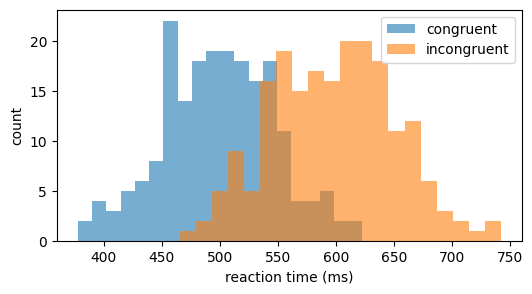

In [50]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(2)              # for reproducibility
congruent = rng.normal(500, 50, 200)        # generate some data from normal dist with same shape, but different means
incongruent = rng.normal(600, 50, 200)

# set up subplots and fig size
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(congruent, bins=20, alpha=0.6, label="congruent")        # alpha == transparency
ax.hist(incongruent, bins=20, alpha=0.6, label="incongruent")
ax.set_xlabel("reaction time (ms)")
ax.set_ylabel("count")
ax.legend()

# force draw 
plt.show()


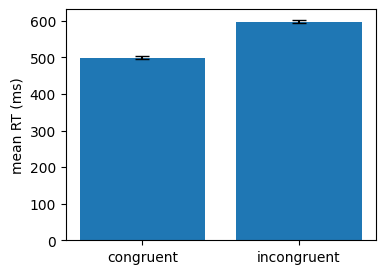

In [51]:
# a bar chart of condition means with standard-error bars
conds = ["congruent", "incongruent"]
data = [congruent, incongruent]
means = [d.mean() for d in data]
sems = [d.std(ddof=1) / np.sqrt(len(d)) for d in data]   # SEM, with sample SD

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(conds, means, yerr=sems, capsize=5)
ax.set_ylabel("mean RT (ms)")
plt.show()

## 8. Mini-project: analyze a simulated experiment

Let's tie some of these topics together. Simulate data from a Stroop-like experiment, then summarize and
plot the congruency effect. This will make use of a list, a dict, NumPy, pandas, and matplotlib in
one short pipeline.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Simulate 12 subjects, 40 trials each, two conditions
records = []
for subj in range(1, 13):
    subject_effect = rng.normal(0, 30)            # each person is a bit faster/slower
    for _ in range(40):
        cond = rng.choice(["congruent", "incongruent"])
        base = 520 if cond == "congruent" else 600
        rt = base + subject_effect + rng.normal(0, 40)
        records.append((subj, cond, rt))

df = pd.DataFrame(records, columns=["subject", "condition", "rt"])
print(df.shape)
df.head()

(480, 3)


,subject,condition,rt
0,1,incongruent,629.388813
1,1,congruent,527.967911
2,1,congruent,538.235709
3,1,incongruent,655.931908
4,1,incongruent,575.622497


In [54]:
# Summarize within-subject, then across subjects
per_subj = df.groupby(["subject", "condition"])["rt"].mean().reset_index()
summary = per_subj.groupby("condition")["rt"].agg(["mean", "std", "count"])
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary

,mean,std,count,sem
condition,,,,
congruent,501.836281,35.058499,12,10.120517
incongruent,585.390887,35.438080,12,10.230092


In [55]:
# the congruency effect, computed per subject (the within-subject difference)
wide = per_subj.pivot(index="subject", columns="condition", values="rt")
effect = wide["incongruent"] - wide["congruent"]
print(f"mean congruency effect: {effect.mean():.1f} ms")
print(f"every subject positive? {(effect > 0).all()}")

mean congruency effect: 83.6 ms
every subject positive? True


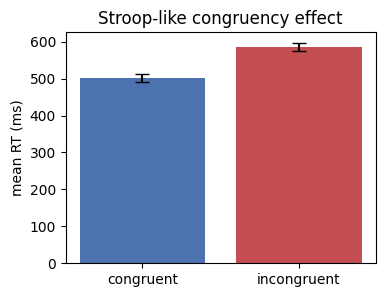

In [56]:
# Plot condition means with SEM error bars
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(summary.index, summary["mean"], yerr=summary["sem"], capsize=5,
       color=["#4C72B0", "#C44E52"])
ax.set_ylabel("mean RT (ms)")
ax.set_title("Stroop-like congruency effect")
plt.show()

## Next steps

You now have a working vocabulary: types, containers, control flow, functions,
arrays, tables, and plots. To learn in more depth:

* Work through the full chapters **P01-P09** as they explain *why* behind
  everything here and cover important details and tools that this short tutorial skipped.
* Read each chapter's **"Applications and advanced tips"** companion for
  psychology/neuroscience examples and the traps to avoid.
* Before you start using an AI assistant to write code, read **Appendix B: Coding
  with AI** first, especially the section on code that runs but is wrong!